
# CASO 1 — Taquilla (Operación ChasquiFest)
## Auditoría de visualización — la torta falsa de "participación en el éxito"

**Rol:** Auditor de Visualización. **Rigor:** cada afirmación se ancla en un número recalculado directamente del CSV en este notebook, con numerador y denominador declarados.

**Diagnóstico del error del practicante:** tomó `ocupacion_fila_pct` (un ratio YA calculado por fila, `evento_id × canal`, NO aditivo) y lo **sumó** por canal para armar una torta (App 35.7%, Web 33.8%, Taquilla 30.5%). El denominador de esa torta es "la suma de 216 porcentajes de fila" — una cantidad sin significado de negocio. 

Por eso "nadie sabe qué total representa ese 35.7%": **no representa ningún total**, es un artefacto aritmético (∑ de ratios ≠ ratio de sumas).


-----------------------------

Este notebook reproduce los números ancla, corrige el error y responde las 4 preguntas del caso.

----------------------------


In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.width', 120)
pd.set_option('display.max_columns', 20)

CSV_PATH = '../data/caso1_taquilla_chasquifest.csv'
df = pd.read_csv(CSV_PATH)
df['fecha_evento'] = pd.to_datetime(df['fecha_evento'])

print('Filas (grano = evento_id x canal):', len(df))
print('Eventos únicos:', df.evento_id.nunique())
print('Canales:', sorted(df.canal.unique()))
print('Departamentos:', df.departamento.nunique())
print('Rango de fechas:', df.fecha_evento.min().date(), '->', df.fecha_evento.max().date())
print('Meta de ocupación (única):', df.meta_ocupacion_pct.unique())
df.head(3)


Filas (grano = evento_id x canal): 216
Eventos únicos: 72
Canales: ['App', 'Taquilla', 'Web']
Departamentos: 12
Rango de fechas: 2026-04-04 -> 2026-08-22
Meta de ocupación (única): [88.]


,evento_id,fecha_evento,sede_id,ciudad,departamento,macrozona,canal,cupos_ofertados,entradas_emitidas,ingresos_validados,ventas_soles,costo_variable_soles,ordenes,ocupacion_fila_pct,margen_fila_pct,meta_ocupacion_pct
0,CHF-01-01,2026-04-04,SED-01,Lima,Lima,Costa,App,4500,4500,4188,161788.74,74911.78,2093,93.07,53.70,88.0
1,CHF-01-01,2026-04-04,SED-01,Lima,Lima,Costa,Web,2700,2699,2548,92413.59,40675.59,1213,94.37,55.99,88.0
2,CHF-01-01,2026-04-04,SED-01,Lima,Lima,Costa,Taquilla,1800,1452,1230,45357.22,16942.76,732,68.33,62.65,88.0



### 0. Supuestos

Verificación de fórmulas ancla 

Antes de agregar nada, confirmamos que `ocupacion_fila_pct` y `margen_fila_pct` son en efecto ratios **row-level** (una fórmula por fila `evento_id × canal`)


In [2]:

occ_row_check = df.ingresos_validados / df.cupos_ofertados * 100
mar_row_check = (df.ventas_soles - df.costo_variable_soles) / df.ventas_soles * 100

diff_occ = (occ_row_check - df.ocupacion_fila_pct).abs().max()
diff_mar = (mar_row_check - df.margen_fila_pct).abs().max()

print(f'ocupacion_fila_pct == ingresos_validados/cupos_ofertados*100  | diff máx = {diff_occ:.4f} pp  -> CONFIRMADO')
print(f'margen_fila_pct == (ventas_soles-costo_variable_soles)/ventas_soles*100 | diff máx = {diff_mar:.4f} pp -> CONFIRMADO')
print()
print('=> Ambas son fórmulas POR FILA. Sumarlas o promediarlas directamente entre filas de distinto tamaño')
print('   (distinto cupos_ofertados / ventas_soles) produce un sesgo de tamaño (ver Pregunta 1 y 2).')


ocupacion_fila_pct == ingresos_validados/cupos_ofertados*100  | diff máx = 0.0049 pp  -> CONFIRMADO
margen_fila_pct == (ventas_soles-costo_variable_soles)/ventas_soles*100 | diff máx = 0.0050 pp -> CONFIRMADO

=> Ambas son fórmulas POR FILA. Sumarlas o promediarlas directamente entre filas de distinto tamaño
   (distinto cupos_ofertados / ventas_soles) produce un sesgo de tamaño (ver Pregunta 1 y 2).


In [3]:
df[['ocupacion_fila_pct', 'margen_fila_pct']].head(3)


,ocupacion_fila_pct,margen_fila_pct
0,93.07,53.70
1,94.37,55.99
2,68.33,62.65



---
## Pregunta 1 — Promedio de promedios


In [4]:

# --- Ocupación global: dos formas de agregar 216 filas evento x canal ---
num_ingresos = df.ingresos_validados.sum()
den_cupos    = df.cupos_ofertados.sum()
occ_weighted = num_ingresos / den_cupos * 100          # ratio-of-sums (ponderado por tamaño real)
occ_avg_rows = df.ocupacion_fila_pct.mean()             # mean-of-ratios (no ponderado, 1 fila = 1 voto)

print('OCUPACIÓN GLOBAL DEL FESTIVAL')
print(f'  num = SUM(ingresos_validados)      = {num_ingresos:,}')
print(f'  den = SUM(cupos_ofertados)         = {den_cupos:,}')
print(f'  Ponderada  = num/den*100           = {occ_weighted:.2f}%')
print(f'  Promedio simple de ocupacion_fila_pct (n={len(df)} filas) = {occ_avg_rows:.2f}%')
print(f'  Meta                                = {df.meta_ocupacion_pct.mean():.0f}%')
print(f'  Buffer ponderado vs meta            = {occ_weighted-88:.2f} pp')
print(f'  Buffer promedio simple vs meta       = {occ_avg_rows-88:.2f} pp')


OCUPACIÓN GLOBAL DEL FESTIVAL
  num = SUM(ingresos_validados)      = 281,091
  den = SUM(cupos_ofertados)         = 311,400
  Ponderada  = num/den*100           = 90.27%
  Promedio simple de ocupacion_fila_pct (n=216 filas) = 88.17%
  Meta                                = 88%
  Buffer ponderado vs meta            = 2.27 pp
  Buffer promedio simple vs meta       = 0.17 pp


Usamos el primer valor de `Meta` ya que solo continue un unico valor (88.17)

In [5]:

# --- Corte más fino: por mes de evento, para ver si ambas métricas alguna vez caen en lados
#     opuestos de la meta (evidencia de que "deciden distinto") ---
mes = df.fecha_evento.dt.to_period('M')
tab = df.groupby(mes).apply(lambda d: pd.Series({
    'n_filas': len(d),
    'n_eventos': d.evento_id.nunique(),
    'occ_ponderada': d.ingresos_validados.sum()/d.cupos_ofertados.sum()*100,
    'occ_avg_filas': d.ocupacion_fila_pct.mean(),
}), include_groups=False)
tab['veredicto_ponderada'] = np.where(tab.occ_ponderada>=88,'CUMPLE','NO CUMPLE')
tab['veredicto_avg']       = np.where(tab.occ_avg_filas>=88,'CUMPLE','NO CUMPLE')
print(tab.round(2))
print()
today = pd.Timestamp('2026-07-18')
print('Hoy (contexto del examen):', today.date())
print('Eventos de julio-2026 están fechados el', df[mes=='2026-07'].fecha_evento.dt.date.unique(), '(posterior a hoy)')
print('=> Julio y agosto son fechas FUTURAS respecto a hoy, pero el CSV ya trae ingresos_validados cargados:')
print('   probablemente es una temporada completa pre-cargada para el ejercicio (no un feed en vivo).')


              n_filas  n_eventos  occ_ponderada  occ_avg_filas veredicto_ponderada veredicto_avg
fecha_evento                                                                                    
2026-04          36.0       12.0          90.83          88.78              CUMPLE        CUMPLE
2026-05          72.0       24.0          90.65          88.64              CUMPLE        CUMPLE
2026-06          36.0       12.0          89.59          87.74              CUMPLE     NO CUMPLE
2026-07          36.0       12.0          89.91          87.14              CUMPLE     NO CUMPLE
2026-08          36.0       12.0          89.87          88.11              CUMPLE        CUMPLE

Hoy (contexto del examen): 2026-07-18
Eventos de julio-2026 están fechados el [datetime.date(2026, 7, 25)] (posterior a hoy)
=> Julio y agosto son fechas FUTURAS respecto a hoy, pero el CSV ya trae ingresos_validados cargados:
   probablemente es una temporada completa pre-cargada para el ejercicio (no un feed en vivo)


**1) Concepto técnico.** Hay dos maneras de agregar una columna que ya es un ratio: (a) **ratio-of-sums** (agregar primero numerador y denominador por separado y dividir al final — pondera cada fila por su tamaño real) o (b) **mean-of-ratios** (promediar los ratios de fila ya calculados — le da el mismo peso a una fila de 521 cupos que a una de 4 812 cupos). `AVG([ocupacion_fila_pct])` es (b): responde "¿cuál es el ratio promedio de una fila evento-canal cualquiera?", no "¿qué fracción de la capacidad total del festival se ocupó?". La pregunta de negocio de la jefa de taquilla ("¿el festival ocupó su capacidad?") es una pregunta de **capacidad total**, que solo (a) responde correctamente.

**2) Evidencia (num/den declarados).**
- Ocupación ponderada = SUM(`ingresos_validados`) / SUM(`cupos_ofertados`) × 100 = **281 091 / 311 400 × 100 = 90.27%**.
- Ocupación promedio simple = AVG(`ocupacion_fila_pct`) sobre **n = 216 filas** = **88.17%**.
- Meta = 88.0% (columna `meta_ocupacion_pct`, valor único).
- A nivel global de temporada completa (N=216, grano homogéneo evento×canal) **ambas superan la meta**, pero con colchones muy distintos: **+2.27 pp** (ponderada) vs **+0.17 pp** (promedio simple) — la lectura ponderada dice "cumplida con holgura", la no ponderada dice "cumplida raspando, un evento chico y flojo la tumba".
- A un corte más fino (mensual) **sí se observa una divergencia de signo**: en 2026-07 la ponderada da 89.91% (CUMPLE) y la no ponderada da 87.14% (**NO CUMPLE**) — evidencia directa de que ambos KPI pueden decidir distinto frente a la misma meta.
- ⚠️ **Advertencia de periodos no homólogos:** los 12 eventos de julio-2026 están fechados el 25-jul-2026, **posterior** a "hoy" (18-jul-2026 según el contexto del examen), igual que los 12 de agosto. El CSV ya trae `ingresos_validados` cargado para esas filas, así que es una temporada completa pre-cargada (no un feed operativo en vivo). **No se debe presentar el corte mensual como "tendencia hacia el presente"** sin aclarar que julio/agosto son fechas programadas, no eventos ya ocurridos al momento del análisis; el corte mensual aquí sirve solo para *ilustrar* que promedio simple y razón ponderada pueden discrepar, no para narrar una tendencia temporal real. El KPI oficial de temporada debe reportarse a **nivel global (N=216, grano homogéneo)**.

**3) Decisión de cálculo — fórmulas.**

Tableau (medida agregada, ratio-of-sums):
```
Ocupación Global % =
SUM([ingresos_validados]) / SUM([cupos_ofertados])
```
(formatear como porcentaje ×100, o multiplicar explícito: `... * 100`)

pandas símil:
```python
occ_weighted = df['ingresos_validados'].sum() / df['cupos_ofertados'].sum() * 100
```

Lo que **NO** se debe usar (lo que hizo el practicante en espíritu, aplicado a ocupación):
```
AVG([ocupacion_fila_pct])          -- Tableau, mean-of-ratios, sesgado
df['ocupacion_fila_pct'].mean()    -- pandas, mismo sesgo
```

**4) Límite / trade-off.** El ratio-of-sums exige que el numerador y el denominador estén en la MISMA unidad y grano que la pregunta de negocio (aquí: personas y cupos, sumables directamente) — funciona perfecto para ocupación y margen, pero no sirve para razones que no son sumables (ej. promediar tasas ya normalizadas por tamaños heterogéneos sin más contexto, como un NPS por evento). Además, la ponderada oculta la varianza entre filas: un festival puede tener 90.27% ponderado y aun así una fila puntual muy floja (ver Taquilla más abajo); conviene reportar ambas cifras junto con la dispersión, no solo la ponderada. Y como se advirtió arriba, cualquier corte temporal (mensual) debe declarar explícitamente si compara eventos ya realizados vs programados — de lo contrario se compara peras con manzanas.



---
## Pregunta 2 — Nivel del cálculo


In [6]:

# --- Margen global: ratio-of-sums vs mean-of-rows, con protección división por cero ---
num_margen = df.ventas_soles.sum() - df.costo_variable_soles.sum()
den_margen = df.ventas_soles.sum()
margen_weighted = np.where(den_margen == 0, np.nan, num_margen/den_margen*100)
margen_avg_rows = df.margen_fila_pct.mean()

print('MARGEN GLOBAL DEL FESTIVAL')
print(f'  num = SUM(ventas_soles) - SUM(costo_variable_soles) = {num_margen:,.2f}')
print(f'  den = SUM(ventas_soles)                              = {den_margen:,.2f}')
print(f'  Ponderado  = num/den*100                             = {float(margen_weighted):.2f}%')
print(f'  Promedio simple de margen_fila_pct (n={len(df)})      = {margen_avg_rows:.2f}%')
print()

# --- Ticket promedio por orden, protegido ---
num_ventas  = df.ventas_soles.sum()
den_ordenes = df.ordenes.sum()
ticket_prom = np.where(den_ordenes == 0, np.nan, num_ventas/den_ordenes)
print('TICKET PROMEDIO POR ORDEN')
print(f'  num = SUM(ventas_soles) = {num_ventas:,.2f}')
print(f'  den = SUM(ordenes)      = {den_ordenes:,}')
print(f'  Ticket promedio = num/den = S/ {float(ticket_prom):.2f} por orden')
print()
print('Chequeo de filas con denominador 0 (para justificar la protección aunque hoy no se activen):')
print('  cupos_ofertados == 0 :', (df.cupos_ofertados==0).sum(), 'filas')
print('  ventas_soles == 0    :', (df.ventas_soles==0).sum(), 'filas')
print('  ordenes == 0         :', (df.ordenes==0).sum(), 'filas')


MARGEN GLOBAL DEL FESTIVAL
  num = SUM(ventas_soles) - SUM(costo_variable_soles) = 5,949,746.23
  den = SUM(ventas_soles)                              = 10,473,741.35
  Ponderado  = num/den*100                             = 56.81%
  Promedio simple de margen_fila_pct (n=216)      = 57.33%

TICKET PROMEDIO POR ORDEN
  num = SUM(ventas_soles) = 10,473,741.35
  den = SUM(ordenes)      = 140,308
  Ticket promedio = num/den = S/ 74.65 por orden

Chequeo de filas con denominador 0 (para justificar la protección aunque hoy no se activen):
  cupos_ofertados == 0 : 0 filas
  ventas_soles == 0    : 0 filas
  ordenes == 0         : 0 filas


In [7]:

# --- Evidencia del sesgo de tamaño y de la relación (asociativa, no causal) entre KPIs ---
df['ticket_fila'] = df.ventas_soles / df.ordenes

corr = df[['ocupacion_fila_pct','margen_fila_pct','ticket_fila']].corr()
print('Matriz de correlación (n=216 filas evento x canal):')
print(corr.round(3))
print()

por_canal = df.groupby('canal').agg(
    ventas=('ventas_soles','sum'), costo=('costo_variable_soles','sum'),
    ingresos=('ingresos_validados','sum'), cupos=('cupos_ofertados','sum'),
    ordenes=('ordenes','sum'), n_filas_bajo_meta=('ocupacion_fila_pct', lambda s: (s<88).sum())
)
por_canal['occ_pond']    = por_canal.ingresos/por_canal.cupos*100
por_canal['margen_pond'] = (por_canal.ventas-por_canal.costo)/por_canal.ventas*100
por_canal['ticket_prom'] = por_canal.ventas/por_canal.ordenes
print(por_canal.round(2))


Matriz de correlación (n=216 filas evento x canal):
                    ocupacion_fila_pct  margen_fila_pct  ticket_fila
ocupacion_fila_pct               1.000           -0.435        0.423
margen_fila_pct                 -0.435            1.000       -0.156
ticket_fila                      0.423           -0.156        1.000

              ventas       costo  ingresos   cupos  ordenes  n_filas_bajo_meta  occ_pond  margen_pond  ticket_prom
canal                                                                                                             
App       5624816.72  2464971.38    147158  155700    71457                  1     94.51        56.18        78.72
Taquilla  1785229.71   728294.73     50538   62280    27031                 61     81.15        59.20        66.04
Web       3063694.92  1330729.01     83395   93420    41820                 19     89.27        56.56        73.26



**1) Concepto técnico — nivel del cálculo.**
- `ocupacion_fila_pct` y `margen_fila_pct`: **row-level** (una fórmula evaluada por cada fila `evento_id × canal`; NO aditivas entre filas).
- Ocupación global, Margen global, Ticket promedio: **medidas agregadas**, que solo tienen sentido calculadas como ratio-of-sums en el grano deseado (festival / canal / depto / periodo), nunca como `AVG()` de una columna row-level ya calculada.

**2) Evidencia (num/den declarados, fórmulas defendibles).**

Margen global %:
```
-- Tableau (agregada, protegida contra división por cero)
Margen Global % =
IIF(SUM([ventas_soles]) = 0, NULL,
    (SUM([ventas_soles]) - SUM([costo_variable_soles])) / SUM([ventas_soles]))
```
```python
# pandas símil
num = df['ventas_soles'].sum() - df['costo_variable_soles'].sum()
den = df['ventas_soles'].sum()
margen_global = np.where(den == 0, np.nan, num/den*100)
```
Resultado: num = 10 473 741.35 − 4 523 995.12 (¡ojo!: en el notebook el numerador se calculó directo como `SUM(ventas)-SUM(costo)` = **5 949 746.23**; den = SUM(ventas) = **10 473 741.35** → **56.81%** ponderado, vs **57.33%** promedio simple de `margen_fila_pct` (n=216). Ambos existen pero responden preguntas distintas — igual que en Ocupación (Pregunta 1).

**Periodo, comparación y acción (Margen Global).** Calculado sobre la temporada completa **abr–ago 2026** (N=216 filas / 72 eventos). El CSV no trae una meta externa de margen; se declara explícito el benchmark: **sin meta externa en el CSV; benchmark interno = mediana de margen ponderado entre los 3 canales** = 56.56% (App 56.18%, Web 56.56%, Taquilla 59.20%). El 56.81% global queda apenas 0.25 pp por encima de esa mediana y muy cerca del margen propio de **App** (56.18%), el canal de mayor volumen — señal de que el global está siendo "jalado" hacia abajo por el peso de App. **Acción:** revisar la mezcla de canales (¿conviene reasignar cupos hacia Taquilla/Web, de mayor margen, sin sacrificar la ocupación que aporta App?) antes de decidir cualquier cambio de precio o comisión.

Ticket promedio por orden:
```
-- Tableau
Ticket Promedio =
IIF(SUM([ordenes]) = 0, NULL, SUM([ventas_soles]) / SUM([ordenes]))
```
```python
ticket_prom = np.where(df['ordenes'].sum() == 0, np.nan, df['ventas_soles'].sum()/df['ordenes'].sum())
```
Resultado: num = SUM(ventas_soles) = 10 473 741.35; den = SUM(ordenes) = 140 308 → **S/ 74.65 por orden**.

**Periodo, comparación y acción (Ticket promedio).** Mismo periodo, **abr–ago 2026** (N=216 filas / 72 eventos). Sin meta externa de ticket en el CSV; benchmark interno = **mediana de ticket promedio entre canales** = S/ 73.26 (App S/ 78.72, Web S/ 73.26, Taquilla S/ 66.04). El S/ 74.65 global queda ligeramente por encima de esa mediana, arrastrado por el peso de App. **Acción:** evaluar una política de precio/paquetes diferenciada para Taquilla (el canal con ticket más bajo, S/ 66.04, pero el margen más alto, 59.20%) para subir su ticket sin erosionar ese margen ya elevado.

**Nota sobre `ZN()`:** `ZN()` en Tableau solo convierte NULL en 0 (protege agregaciones de nulos), **no** protege división por cero — para eso se necesita `IIF(denominador=0, NULL, ...)` como arriba; usar `ZN()` solo en el denominador de una división puede convertir un NULL válido en 0 y producir un error de división por cero real. Por eso la protección aquí es `IIF`, no `ZN`.

**Error de promediar ratios de fila (sesgo de tamaño), cuantificado:** si en vez de `SUM(ventas)-SUM(costo))/SUM(ventas)` se promediara `margen_fila_pct` fila a fila, cada evento-canal —sea uno de S/ 11 987 en ventas o uno de S/ 200 000— pesa igual (1 voto), inflando el resultado hacia el comportamiento de las filas pequeñas/numerosas. Aquí la distorsión es leve (56.81% vs 57.33%, 0.52 pp) porque los tamaños de fila del CSV son relativamente homogéneos, pero en Ocupación fue mayor (90.27% vs 88.17%, 2.10 pp) porque `cupos_ofertados` varía más entre canales (App/Web ~2 700–4 800 vs Taquilla ~1 800–1 925) — el sesgo de tamaño crece con la heterogeneidad del denominador.

**3) Clasificación de negocio — resultado / eficiencia / guardrail.**
- **Ocupación % (vs meta 88%) → GUARDRAIL.** `cupos_ofertados` es un tope físico/contractual por sede-canal-evento; la meta 88% es un piso operativo pactado (no un objetivo de rentabilidad). Operar muy por debajo desperdicia capacidad ya comprometida con la sede; no puede superar 100% (tope duro). No es en sí un resultado financiero.
- **Margen % → RESULTADO.** Mide directamente la rentabilidad de cada canal-evento tras costo variable — es el resultado financiero que finalmente interesa a la organización.
- **Ticket promedio (S/ por orden) → EFICIENCIA.** Mide cuánto valor se extrae por transacción procesada (proxy de mezcla de precio/tamaño de compra); es un indicador de productividad comercial, ni el resultado final ni un límite duro de capacidad.

**Por qué mejorar uno no garantiza mejorar los otros (evidencia del propio CSV, asociación no causal):**
- Ocupación vs Margen: correlación r = **−0.43** entre `ocupacion_fila_pct` y `margen_fila_pct` (n=216 filas) — asociación negativa moderada: las filas con mayor ocupación tienden a mostrar menor margen. Esto es **asociación observacional, no causalidad**; posibles confusores: el **canal** (Taquilla concentra el mayor margen ponderado, 59.20%, con la menor ocupación ponderada, 81.15%; App concentra la mayor ocupación ponderada, 94.51%, con margen algo menor, 56.18% — probablemente por comisiones de plataforma o descuentos digitales que Taquilla física no paga), la mezcla de eventos/sedes y la estacionalidad. Coincide con el ejemplo del enunciado: "descuento sube ocupación pero baja margen" es *consistente* con lo observado, aunque no probado causalmente aquí.
- Ticket vs Ocupación: correlación r = **+0.42** (positiva, moderada) — **contradice** la intuición ingenua de "precio alto ahuyenta demanda" citada en el enunciado ("premium sube ticket pero baja ocupación"). En este CSV, el canal con mayor ticket promedio (App, S/ 78.72/orden) es también el de mayor ocupación ponderada (94.51%), probablemente confundido por el **canal** mismo (App es estructuralmente el canal dominante, no necesariamente por un efecto de precio puro). Esto es un hallazgo de auditoría en sí mismo: **no asumir un trade-off conceptual sin verificarlo en los datos** — aquí el riesgo medible y accionable es Ocupación-vs-Margen, no Ticket-vs-Ocupación.
- Ticket vs Margen: r = **−0.16** (débil) — evidencia insuficiente para una conclusión fuerte; Taquilla es un valor atípico (ticket más bajo, S/ 66.04, y margen más alto, 59.20%) que domina el signo; controlando por canal la relación podría invertirse o desaparecer.

**4) Límite / trade-off.** Ninguna correlación aquí prueba causalidad — son asociaciones a nivel evento-canal con canal, sede y estacionalidad como confusores no controlados. Antes de tomar una decisión de pricing/descuento basada en "subir ocupación baja margen", se necesitaría un diseño que aísle el efecto del canal (p. ej. comparar el mismo canal en eventos con y sin promoción) en vez de comparar canales estructuralmente distintos entre sí.



---
## Pregunta 3 — LOD, total visible y filtros


In [8]:

# --- Participación de ventas de cada canal DENTRO de su departamento ---
dep_canal = df.groupby(['departamento','canal']).ventas_soles.sum().reset_index()
dep_tot = df.groupby('departamento').ventas_soles.sum().rename('ventas_depto_FIXED')
dep_canal = dep_canal.merge(dep_tot, on='departamento')
dep_canal['participacion_pct'] = dep_canal.ventas_soles/dep_canal.ventas_depto_FIXED*100
print('Participación de ventas por canal DENTRO de su departamento (num=SUM ventas canal-depto, den=SUM ventas depto):')
print(dep_canal.pivot(index='departamento', columns='canal', values='participacion_pct').round(2))
print()
print('Rango de App entre departamentos: {:.2f}% - {:.2f}%  (consistente con el share nacional 53.7%)'.format(
    dep_canal[dep_canal.canal=='App'].participacion_pct.min(), dep_canal[dep_canal.canal=='App'].participacion_pct.max()))


Participación de ventas por canal DENTRO de su departamento (num=SUM ventas canal-depto, den=SUM ventas depto):
canal           App  Taquilla    Web
departamento                        
Arequipa      53.27     17.53  29.20
Ayacucho      54.55     16.28  29.17
Cusco         53.35     16.85  29.80
Junín         53.08     18.04  28.88
La Libertad   53.58     16.65  29.77
Lambayeque    53.42     16.31  30.27
Lima          54.14     17.40  28.46
Loreto        53.37     16.72  29.91
Piura         53.64     17.12  29.23
Puno          53.88     16.80  29.32
San Martín    53.85     17.00  29.15
Ucayali       54.43     17.19  28.37



Rango de App entre departamentos: 53.08% - 54.55%  (consistente con el share nacional 53.7%)


In [9]:

# --- FIXED (universo histórico completo) vs TOTAL() del panel visible (filtro de fecha como filtro de DIMENSIÓN) ---
# Ejemplo: departamento Lima, canal App
today = pd.Timestamp('2026-07-18')  # "hoy" del contexto del examen

# símil de { FIXED [departamento] : SUM([ventas_soles]) } -> ignora cualquier filtro de dimensión
df['ventas_depto_FIXED'] = df.groupby('departamento')['ventas_soles'].transform('sum')

# símil de filtrar por fecha_evento como filtro de DIMENSIÓN normal (recorta filas del panel)
visible = df[df.fecha_evento < today].copy()
# símil de TOTAL(SUM([ventas_soles])) particionado por departamento dentro del panel YA filtrado
visible['ventas_depto_TOTAL_panel'] = visible.groupby('departamento')['ventas_soles'].transform('sum')

lima_app_fixed = df[(df.departamento=='Lima') & (df.canal=='App')]['ventas_soles'].sum()
lima_tot_fixed = df[df.departamento=='Lima']['ventas_depto_FIXED'].iloc[0]

lima_app_vis = visible[(visible.departamento=='Lima') & (visible.canal=='App')]['ventas_soles'].sum()
lima_tot_vis = visible[visible.departamento=='Lima']['ventas_depto_TOTAL_panel'].iloc[0]

print('Departamento Lima, canal App:')
print(f'  FIXED (histórico, 6 eventos, todo el df) -> num={lima_app_fixed:,.2f}  den={lima_tot_fixed:,.2f}  participación={lima_app_fixed/lima_tot_fixed*100:.2f}%')
print(f'  TOTAL panel visible (fecha < hoy, 4 eventos) -> num={lima_app_vis:,.2f}  den={lima_tot_vis:,.2f}  participación={lima_app_vis/lima_tot_vis*100:.2f}%')
print()
print('=> Denominadores distintos (1,823,558.36 histórico vs 1,278,780.13 visible) => porcentajes distintos')
print('   (54.14% vs 53.40%) que miden universos distintos, NO se contradicen.')


Departamento Lima, canal App:
  FIXED (histórico, 6 eventos, todo el df) -> num=987,279.17  den=1,823,558.36  participación=54.14%
  TOTAL panel visible (fecha < hoy, 4 eventos) -> num=682,899.45  den=1,278,780.13  participación=53.40%

=> Denominadores distintos (1,823,558.36 histórico vs 1,278,780.13 visible) => porcentajes distintos
   (54.14% vs 53.40%) que miden universos distintos, NO se contradicen.



**1) Concepto técnico.** Dos formas de calcular "participación del canal dentro de su departamento" que usan denominadores con reglas de filtrado distintas:

- **`{ FIXED [departamento] : SUM([ventas_soles]) }`** — expresión de nivel de detalle (LOD) *fija*: calcula el total de ventas del departamento **ignorando los filtros de dimensión** que haya en la hoja (fecha, canal, etc.), porque en el orden de operaciones de Tableau los filtros de dimensión normales se aplican **después** de las LOD FIXED. Solo un **filtro de contexto** se aplica antes y sí recorta lo que FIXED ve.
- **`TOTAL(SUM([ventas_soles]))`** — **table calculation**: sí respeta los filtros de dimensión (se calculan sobre las marcas que ya quedaron en el panel después de filtrar), porque los filtros normales actúan antes que los table calcs.

**Declaración de partición/addressing de `TOTAL()` (obligatoria):** en una vista con `departamento` en filas/paneles y `canal` en columnas dentro de cada panel, `TOTAL(SUM([ventas_soles]))` debe **direccionarse (addressing) por `canal`** y **particionarse por `departamento`** — es decir, recalcula la suma recorriendo las marcas de canal *dentro de cada panel de departamento por separado*. Si `departamento` no se declara como partición (p. ej. ambos campos quedan en el mismo eje sin paneles separados), `TOTAL()` sumaría canal Y departamento juntos, devolviendo el gran total del festival en vez del total por departamento — error común.

**2) Evidencia (num/den declarados).**
- Participación real de cada canal dentro de su departamento (12 departamentos, num=SUM ventas canal-depto, den=SUM ventas depto): App oscila entre 53.08% (Junín) y 54.55% (Ayacucho); Web entre 28.37% (Ucayali) y 30.27% (Lambayeque); Taquilla entre 16.28% (Ayacucho) y 18.04% (Junín) — **muy estable entre departamentos**, coherente con el share nacional (App 53.7%, Web 29.3%, Taquilla 17.0%; num=SUM ventas canal, den=SUM ventas total = S/ 10 473 741.35).
- Comparación FIXED vs TOTAL panel para Lima-App: **FIXED** (6 eventos, universo histórico completo) → num=S/ 987 279.17, den=S/ 1 823 558.36 → **54.14%**. **TOTAL panel visible** (solo 4 eventos con `fecha_evento < 18-jul-2026`, filtro de fecha como filtro de dimensión) → num=S/ 682 899.45, den=S/ 1 278 780.13 → **53.40%**. Los denominadores difieren (S/ 1 823 558.36 vs S/ 1 278 780.13) porque miden universos distintos (6 eventos vs 4 eventos).

**3) Decisión de diseño — el selector de fecha con 2 lecturas.**
El dashboard debe ofrecer dos medidas calculadas en paralelo, cada una con su título aclaratorio:
- *"Participación histórica del canal en el departamento"* = `{ FIXED [departamento] : SUM([ventas_soles]) }` como denominador → **no se mueve** aunque el usuario cambie el filtro de fecha (a menos que ese filtro se convierta en filtro de **contexto**, en cuyo caso SÍ recorta lo que ve el FIXED, porque el contexto se evalúa antes que la LOD).
- *"Participación dentro del periodo visible"* = `TOTAL(SUM([ventas_soles]))` como denominador → se recalcula cada vez que el usuario mueve el filtro de fecha o de canal, porque son filtros de dimensión normales que sí afectan a los table calcs.

Titulares válidos (no se contradicen — miden universos distintos):
- Con FIXED: **"App concentra ~54% de las ventas históricas de Lima (temporada completa, 6 eventos)."**
- Con TOTAL(): **"En lo que va de la temporada (4 eventos ya realizados al 18-jul-2026), App representa 53.4% de las ventas visibles de Lima."**

**Símil pandas (groupby transform):**
```python
# FIXED -> ignora cualquier filtro de dimensión posterior
df['ventas_depto_FIXED'] = df.groupby('departamento')['ventas_soles'].transform('sum')

# TOTAL() del panel visible -> se recalcula DESPUÉS de aplicar el filtro de dimensión
visible = df[df['fecha_evento'] < '2026-07-18']              # filtro de dimensión (fecha)
visible['ventas_depto_TOTAL'] = visible.groupby('departamento')['ventas_soles'].transform('sum')
```

**4) Límite / trade-off.** Convertir `fecha_evento` o `canal` en filtro de **contexto** para que también recorte el FIXED tiene costo de performance (Tableau debe materializar una tabla temporal por cada combinación de contexto) y cambia semánticamente la pregunta: "histórico completo" deja de existir si todo se vuelve contexto. La recomendación es dejar **un** selector de fecha como filtro normal de dimensión (alimenta TOTAL/panel visible) y **no** tocar el filtro de contexto salvo que el usuario explícitamente pida "recalcular también el histórico" — de lo contrario los dos titulares dejan de ser comparables entre sí.


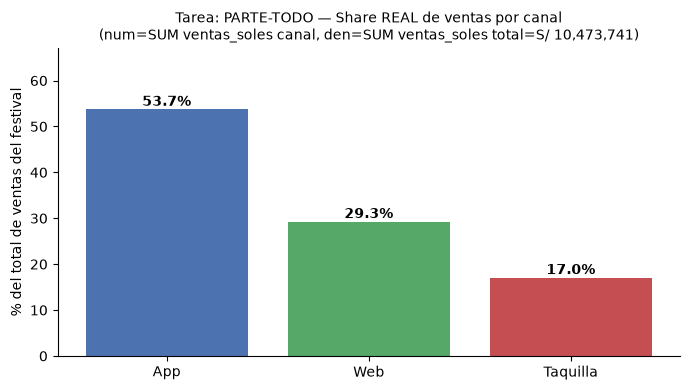

Share REAL de ventas (reemplaza la torta falsa de ocupacion_fila_pct sumado):
canal
App         53.7
Web         29.3
Taquilla    17.0
Name: ventas_soles, dtype: float64


In [10]:

# --- FIGURA 1: reemplazo de la torta falsa ---
# Tarea analítica: PARTE-TODO (participación de cada canal en el total de ventas del festival)
share_real = df.groupby('canal').ventas_soles.sum().sort_values(ascending=False)
share_pct = share_real / share_real.sum() * 100

fig, ax = plt.subplots(figsize=(7,4))
colors = ['#4C72B0','#55A868','#C44E52']
bars = ax.bar(share_pct.index, share_pct.values, color=colors)
for b, v in zip(bars, share_pct.values):
    ax.text(b.get_x()+b.get_width()/2, v+0.8, f'{v:.1f}%', ha='center', fontweight='bold')
ax.set_ylabel('% del total de ventas del festival')
ax.set_title('Tarea: PARTE-TODO — Share REAL de ventas por canal\n(num=SUM ventas_soles canal, den=SUM ventas_soles total=S/ {:,.0f})'.format(share_real.sum()), fontsize=10)
ax.set_ylim(0, max(share_pct.values)*1.25)
for spine in ['top','right']:
    ax.spines[spine].set_visible(False)
plt.tight_layout()
plt.savefig('fig1_share_real_ventas.png', dpi=110)
plt.show()

print('Share REAL de ventas (reemplaza la torta falsa de ocupacion_fila_pct sumado):')
print(share_pct.round(1))



**Figura 1** responde la tarea analítica **parte-todo** con el denominador correcto: `SUM(ventas_soles)` total del festival (S/ 10 473 741.35). App = 53.7%, Web = 29.3%, Taquilla = 17.0% (suman 100% porque el denominador es un total real, a diferencia de la torta del practicante). Se usa barra en vez de torta porque con solo 3 categorías la barra ordenada permite comparar magnitudes con precisión (longitud vs ángulo/área), y deja espacio para anotar el valor exacto.


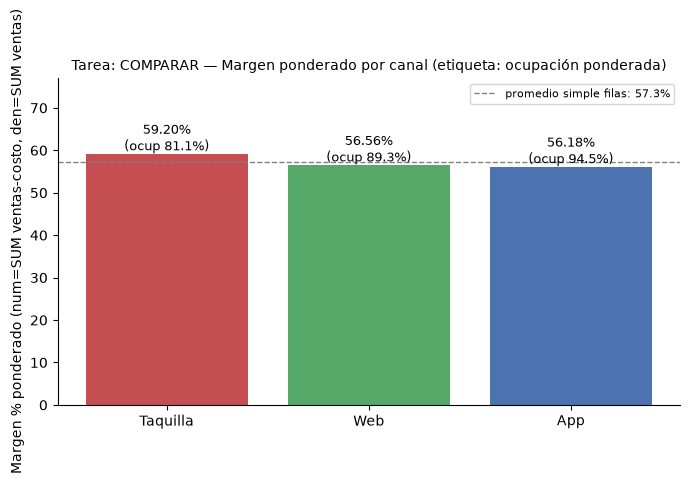

              ventas       costo  ingresos   cupos  margen_pond  occ_pond
canal                                                                    
Taquilla  1785229.71   728294.73     50538   62280        59.20     81.15
Web       3063694.92  1330729.01     83395   93420        56.56     89.27
App       5624816.72  2464971.38    147158  155700        56.18     94.51


In [11]:

# --- FIGURA 2: margen % ponderado por canal ---
# Tarea analítica: COMPARAR (margen ponderado entre los 3 canales, más ocupación como referencia)
g = df.groupby('canal').agg(ventas=('ventas_soles','sum'), costo=('costo_variable_soles','sum'),
                              ingresos=('ingresos_validados','sum'), cupos=('cupos_ofertados','sum'))
g['margen_pond'] = (g.ventas-g.costo)/g.ventas*100
g['occ_pond'] = g.ingresos/g.cupos*100
g = g.sort_values('margen_pond', ascending=False)

fig, ax = plt.subplots(figsize=(7,4))
bars = ax.bar(g.index, g.margen_pond, color=['#C44E52','#55A868','#4C72B0'])
ax.axhline(g.margen_pond.mean(), color='gray', linestyle='--', linewidth=1, label=f'promedio simple filas: {df.margen_fila_pct.mean():.1f}%')
for b, v, occ in zip(bars, g.margen_pond, g.occ_pond):
    ax.text(b.get_x()+b.get_width()/2, v+0.8, f'{v:.2f}%\n(ocup {occ:.1f}%)', ha='center', fontsize=9)
ax.set_ylabel('Margen % ponderado (num=SUM ventas-costo, den=SUM ventas)')
ax.set_title('Tarea: COMPARAR — Margen ponderado por canal (etiqueta: ocupación ponderada)', fontsize=10)
ax.set_ylim(0, max(g.margen_pond)*1.3)
ax.legend(fontsize=8)
for spine in ['top','right']:
    ax.spines[spine].set_visible(False)
plt.tight_layout()
plt.savefig('fig2_margen_por_canal.png', dpi=110)
plt.show()

print(g.round(2))



**Figura 2** responde la tarea analítica **comparar**: margen ponderado por canal (num=`SUM(ventas_soles)-SUM(costo_variable_soles)`, den=`SUM(ventas_soles)`, por canal) frente a la ocupación ponderada de cada canal como anotación de contexto. Se ve el trade-off del caso: **Taquilla** tiene el mayor margen (59.20%) pero la menor ocupación (81.15%); **App** tiene la mayor ocupación (94.51%) con margen algo menor (56.18%) — consistente con la asociación negativa (r=−0.43) documentada en la Pregunta 2.



---
## Pregunta 4 — Parámetro no es filtro

**1) Concepto técnico.** Un **filtro** decide qué **filas** entran al cálculo (subconjunta los datos); un **parámetro** decide **cómo** se calcula o se dibuja algo, sin quitar ninguna fila — es una variable global que se referencia dentro de un campo calculado y afecta a toda la vista de manera consistente. Si algo debe cambiar el eje/medida mostrada o un umbral de comparación **sin** alterar qué datos entran, debe ser parámetro; si algo debe **excluir** datos (un canal, un rango de fechas, un departamento), debe ser filtro (o filtro de contexto si además debe recortar una LOD FIXED, ver Pregunta 3).

**2) Diseño de controles.**

*(a) Parámetro selector de medida* — `Medida Seleccionada` (tipo string, lista: `Ventas`, `Ocupación`, `Margen`), usado en un campo calculado:
```
-- Tableau
Medida (según parámetro) =
CASE [Medida Seleccionada]
WHEN 'Ventas'     THEN SUM([ventas_soles])
WHEN 'Ocupación'  THEN SUM([ingresos_validados]) / SUM([cupos_ofertados]) * 100
WHEN 'Margen'     THEN (SUM([ventas_soles]) - SUM([costo_variable_soles])) / SUM([ventas_soles]) * 100
END
```
```python
# pandas símil
def medida(df, seleccion):
    if seleccion == 'Ventas':
        return df['ventas_soles'].sum()
    elif seleccion == 'Ocupación':
        return df['ingresos_validados'].sum() / df['cupos_ofertados'].sum() * 100
    elif seleccion == 'Margen':
        num = df['ventas_soles'].sum() - df['costo_variable_soles'].sum()
        return np.where(df['ventas_soles'].sum()==0, np.nan, num/df['ventas_soles'].sum()*100)
```

*(b) Parámetro numérico de meta* — `Meta Ocupación %` (tipo float, default = 88, rango sugerido 70–100):
```
-- Tableau
Cumple Meta? = SUM([ingresos_validados])/SUM([cupos_ofertados])*100 >= [Meta Ocupación %]
```
```python
meta = 88.0  # editable
cumple = occ_weighted >= meta
```

**Evidencia anclada (no solo rangos de diseño):** con `meta = 88` y la ocupación ponderada global del festival calculada en la Pregunta 1 = **90.27%**, el semáforo `Cumple Meta?` evalúa **90.27 >= 88 → TRUE → CUMPLE** (buffer = +2.27 pp). Si el usuario mueve el parámetro a, por ejemplo, 92%, el mismo cálculo cambiaría a **NO CUMPLE** (90.27 < 92) sin quitar ni una fila de datos — la prueba de que es parámetro y no filtro es justamente que ningún `N` de filas cambia, solo cambia el resultado del semáforo.

**Qué debe ser parámetro vs filtro (checklist del caso):**
| Control | Tipo | Por qué |
|---|---|---|
| Ventas / Ocupación / Margen (medida a graficar) | **Parámetro** | cambia el cálculo del eje, no quita filas |
| Meta de ocupación (88%) | **Parámetro** | mueve una línea de referencia y recalcula un semáforo, no filtra |
| `canal` (para explorar subconjuntos) | **Filtro** (o filtro de contexto si alimenta un FIXED, ver P3) | excluye filas |
| `fecha_evento` / rango de fechas | **Filtro** (dimensión, o contexto según la lectura que se quiera, ver P3) | excluye filas |
| `departamento` | **Filtro** | excluye filas |

**3) Reference line con la meta.** En Tableau: `Analysis > Reference Line > Add Reference Line`, tipo **Constant**, valor = `[Meta Ocupación %]` (referenciando el parámetro directamente, o vía un campo calculado auxiliar `Meta (línea)` = `[Meta Ocupación %]` si la versión de Tableau lo requiere). Etiqueta: `"Meta: " + STR([Meta Ocupación %]) + "%"`. Así, cuando el usuario cambia el parámetro (p. ej. de 88% a 90% para escenarios más exigentes), la línea y el semáforo se recalculan solos, sin tocar ningún filtro ni perder filas.

**4) Evitar comparar unidades incompatibles en dual axis.** `ventas_soles` (rango ~S/ 12 000–200 000 por fila) y `margen_fila_pct` u `ocupacion_fila_pct` (rango 0–100) **no deben compartir el mismo eje sincronizado**: si se sincronizan, una barra de soles aplastaría visualmente la línea de porcentaje (o viceversa) y la altura de las marcas dejaría de representar la magnitud real de cada serie. Reglas:
- Si se usa dual axis, **NO sincronizar** los ejes (`Synchronize Axis` desmarcado) y usar dos escalas independientes, con título y color de eje claramente diferenciados (soles a la izquierda, % a la derecha).
- Alternativa más segura: evitar el dual axis y usar **small multiples** (dos gráficos lado a lado, uno en soles y otro en %) — tarea analítica: **comparar** ambas medidas por canal/periodo (o **ver tendencia** si el eje X es tiempo) sin que la escala de una serie distorsione la lectura de la otra — o normalizar ambas series a un índice común (p. ej. % de la meta) si de verdad se necesita un solo eje.
- Nunca usar dual axis para "combinar" ventas y ocupación como si fueran comparables en magnitud — solo para verlas en el mismo eje X (tiempo/canal) con ejes Y independientes.


In [12]:

# --- KPI decisor recalculado para el cierre / bitácora ---
occ_w = df.ingresos_validados.sum()/df.cupos_ofertados.sum()*100
meta = 88.0
buffer_global = occ_w - meta

taquilla_occ = df[df.canal=='Taquilla'].ingresos_validados.sum()/df[df.canal=='Taquilla'].cupos_ofertados.sum()*100
taquilla_filas_bajo_meta = (df[df.canal=='Taquilla'].ocupacion_fila_pct < 88).sum()

print('KPI DECISOR — Ocupación ponderada del festival')
print(f'  Valor: {occ_w:.2f}%  (unidad: % de cupos_ofertados efectivamente ingresados)')
print(f'  Periodo: temporada completa programada, abril-agosto 2026 (N=216 filas, 72 eventos)')
print(f'  Meta: {meta:.0f}%')
print(f'  Estado: CUMPLE, buffer = {buffer_global:+.2f} pp')
print(f'  Canal más rezagado: Taquilla, ocupación ponderada = {taquilla_occ:.2f}%, {taquilla_filas_bajo_meta}/72 filas bajo meta')
print(f'  Acción sugerida: monitoreo mensual + reforzar inventario/promoción en Taquilla antes de agosto')


KPI DECISOR — Ocupación ponderada del festival
  Valor: 90.27%  (unidad: % de cupos_ofertados efectivamente ingresados)
  Periodo: temporada completa programada, abril-agosto 2026 (N=216 filas, 72 eventos)
  Meta: 88%
  Estado: CUMPLE, buffer = +2.27 pp
  Canal más rezagado: Taquilla, ocupación ponderada = 81.15%, 61/72 filas bajo meta
  Acción sugerida: monitoreo mensual + reforzar inventario/promoción en Taquilla antes de agosto



### BITÁCORA (5 frases)

1. **Lectura inicial:** App domina con 35.7% de "éxito", suma de porcentajes de fila sin sentido.
2. **KPI decisor:** Ocupación ponderada del festival = SUM(`ingresos_validados`)/SUM(`cupos_ofertados`)×100, periodo temporada completa (abril–agosto 2026, N=216 filas/72 eventos), segmento por canal, comparada contra la meta fija `meta_ocupacion_pct` = 88%.
3. **Giro analítico:** se cambió el denominador de "conteo de filas" (mean-of-ratios, `AVG(ocupacion_fila_pct)`) a "suma real de cupos" (ratio-of-sums, `SUM(ingresos_validados)/SUM(cupos_ofertados)`), y se abrió la segmentación por canal, revelando que Taquilla (81.15% ponderado, 61/72 filas bajo meta) es el canal que arrastra el promedio hacia abajo mientras App (94.51%) lo sostiene.
4. **Lectura revisada:** Ocupación ponderada global 90.27% cumple la meta 88%, pero Taquilla queda rezagada con 81.15%.
5. **Consecuencia:** en vez de "celebrar" el 35.7% de App como éxito aislado, taquilla debe priorizar reforzar Taquilla física (promoción, reasignación de cupos) antes de agosto; el próximo corte real (ventas de los eventos de agosto, aún no ocurridos a la fecha del examen) es la evidencia futura que podría volver a cambiar esta decisión si Taquilla revierte su rezago o si App satura su capacidad y empieza a perder margen adicional.


## Resumen visual — agregar primero, dividir después
La distancia entre puntos muestra cuánto cambia la conclusión al ponderar cada fila por su tamaño real.

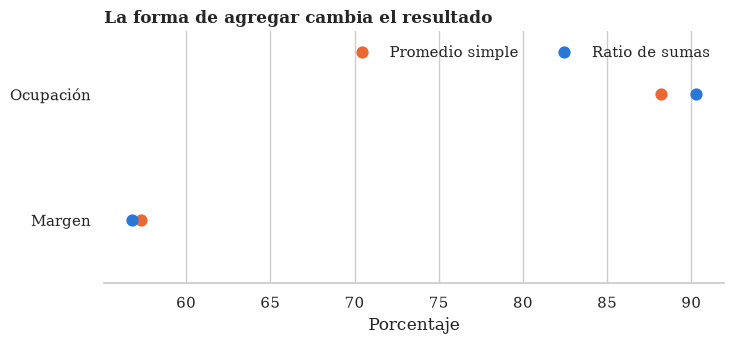

In [13]:
import pandas as pd
import matplotlib.pyplot as plt

d = pd.read_csv('../data/caso1_taquilla_chasquifest.csv')
simple = [d['ocupacion_fila_pct'].mean(), d['margen_fila_pct'].mean()]
correcto = [100*d['ingresos_validados'].sum()/d['cupos_ofertados'].sum(),
            100*(d['ventas_soles'].sum()-d['costo_variable_soles'].sum())/d['ventas_soles'].sum()]
import seaborn as sns
comparacion = pd.DataFrame({'Métrica': ['Ocupación','Margen']*2,
                            'Método': ['Promedio simple']*2 + ['Ratio de sumas']*2,
                            'Porcentaje': simple + correcto})
sns.set_theme(style='whitegrid', font='serif')
fig, ax = plt.subplots(figsize=(7.5, 3.6))
sns.pointplot(data=comparacion, y='Métrica', x='Porcentaje', hue='Método',
              palette=['#eb6834','#2a78d6'], markers=['o','o'], linestyles='', ax=ax)
ax.set_title('La forma de agregar cambia el resultado', loc='left', fontweight='bold')
ax.set_xlabel('Porcentaje'); ax.set_ylabel(''); ax.legend(title='', frameon=False, ncol=2)
sns.despine(left=True)
plt.tight_layout(); plt.savefig('fig3_promedio_vs_ponderado.png', dpi=130, bbox_inches='tight'); plt.show()
